# Credit Card Default – Modeling
### การสร้างโมเดลทำนายการผิดนัดชำระหนี้บัตรเครดิต

**Goal:** predict which customers will default, and explain *why*.

**What EDA told us** (see `02_eda.ipynb`):
- Only 3.3% default → judge models by **recall / precision / AUC**, not accuracy.
- `balance` is the strongest predictor, with an S-shaped jump → **logistic regression** fits this shape.
- Student paradox → `is_student` must be used **together with** `balance`.
- `income` barely matters and overlaps with `is_student` (correlation −0.75).

**Plan:**
1. Split data into train (70%) and test (30%). The test set is not touched until the final check.
2. Baseline: a "model" that always says "No".
3. Logistic regression with `statsmodels` – read the coefficients.
4. Compare 8 models with 10-fold cross-validation on the training set.
5. Tune the cutoff (threshold) on the training set.
6. Final check on the test set, with SQL tables for business use.

**Tools:** Python (statsmodels, scikit-learn) for models, SQL (DuckDB) for evaluation tables from `sql/03_modeling.sql`.

## Guide / คู่มือการอ่าน

**English**
- **What this notebook does:** builds a model that gives every customer a **chance of default** (0–100%), checks how good it is on customers it has never seen, and explains what drives risk.
- **Input:** `data/default_clean.csv`. SQL queries: `sql/03_modeling.sql`.
- **Outputs:** a table in each step, and 4 charts in `outputs/figures/` (`08_…` to `11_…`).
- **Read it in 3 minutes:** skip the code. Read the **Insight** notes, look at the 4 charts and their **How to read** notes, then read **Section 8 – Summary**.

**ภาษาไทย**
- **Notebook นี้ทำอะไร:** สร้างโมเดลที่ให้ **โอกาสผิดนัด** (0–100%) กับลูกค้าทุกคน ตรวจว่าแม่นแค่ไหนกับลูกค้าที่โมเดลไม่เคยเห็น และอธิบายว่าอะไรทำให้เสี่ยง
- **ข้อมูลเข้า:** `data/default_clean.csv` คำสั่ง SQL อยู่ใน `sql/03_modeling.sql`
- **ผลลัพธ์:** ตารางในแต่ละขั้นตอน และกราฟ 4 รูปใน `outputs/figures/` (`08_…` ถึง `11_…`)
- **อ่านจบใน 3 นาที:** ข้ามโค้ดได้ อ่านกล่อง **Insight / ข้อค้นพบ** ดูกราฟ 4 รูปพร้อม **วิธีอ่าน** แล้วอ่าน **หัวข้อ 8 – สรุป**

**Key words / คำสำคัญ**

| Word | Meaning | ความหมาย |
|---|---|---|
| Chance of default | How likely a customer is to not pay (0–100%) | โอกาสที่ลูกค้าจะไม่จ่ายหนี้ (0–100%) |
| Cutoff | If the chance is above this, the customer is flagged | ถ้าโอกาสผิดนัดสูงกว่าค่านี้ ลูกค้าจะถูกแจ้งเตือน |
| Recall | Of all real defaulters, how many we caught | จากคนที่ผิดนัดจริงทั้งหมด จับได้กี่ % |
| Precision | Of all flagged customers, how many really defaulted | จากคนที่ถูกแจ้งเตือน ผิดนัดจริงกี่ % |
| AUC | How well the model ranks risky above safe (0.5 = guessing, 1 = perfect) | ความสามารถจัดอันดับคนเสี่ยงไว้เหนือคนปลอดภัย (0.5 = เดาสุ่ม, 1 = สมบูรณ์แบบ) |
| Odds ratio | How many times the odds of default change | อัตราส่วนที่ "โอกาส (odds)" ผิดนัดเปลี่ยนไปกี่เท่า |

| Figure / กราฟ | Shows / แสดงอะไร |
|---|---|
| `08_logistic_curve.png` | Chance of default at each balance / โอกาสผิดนัดในแต่ละยอดหนี้ |
| `09_threshold_tradeoff.png` | Choosing the cutoff / การเลือกเกณฑ์ตัดสิน |
| `10_confusion_matrices.png` | Right vs wrong predictions / ทายถูก-ทายผิดกี่คน |
| `11_roc_pr_curves.png` | Overall model quality / คุณภาพโมเดลโดยรวม |

## 1. Setup – code only, you can skip / ส่วนตั้งค่า เป็นโค้ด ข้ามได้

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import Markdown, display
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
                             average_precision_score, f1_score, precision_score, recall_score,
                             roc_auc_score)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sql_utils import load_queries

ROOT = Path.cwd()
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42

df = pd.read_csv(ROOT / "data" / "default_clean.csv")
con = duckdb.connect()
queries = load_queries(ROOT / "sql" / "03_modeling.sql")


def run(name, **params):
    """Show the named query from sql/03_modeling.sql, then return its result."""
    note = f"\n\nParameters: `{params}`" if params else ""
    display(Markdown(f"```sql\n{queries[name]}\n```{note}"))
    return (con.execute(queries[name], params) if params else con.execute(queries[name])).df()


sns.set_theme(style="whitegrid")
print(df.shape)
df.head()

(10000, 5)


,customer_id,default_flag,is_student,balance,income
0,1,0,0,729.526495,44361.625074
1,2,0,1,817.180407,12106.134700
2,3,0,0,1073.549164,31767.138947
3,4,0,0,529.250605,35704.493935
4,5,0,0,785.655883,38463.495879


## 2. Train / test split / แบ่งข้อมูลฝึกและข้อมูลทดสอบ
Stratified split keeps the same 3.3% default rate in both parts.

แบ่งข้อมูลเป็น 2 ส่วน: 70% ใช้ฝึกโมเดล และ 30% เก็บไว้ทดสอบตอนท้าย (เหมือน "ข้อสอบ" ที่โมเดลไม่เคยเห็น) ทั้งสองส่วนมีอัตราผิดนัด 3.3% เท่ากัน

In [2]:
train, test = train_test_split(df, test_size=0.3, stratify=df["default_flag"], random_state=SEED)
y_train, y_test = train["default_flag"], test["default_flag"]

pd.DataFrame({
    "rows": [len(train), len(test)],
    "defaulters": [y_train.sum(), y_test.sum()],
    "default_rate_pct": [100 * y_train.mean(), 100 * y_test.mean()],
}, index=["train", "test"]).round(2)

,rows,defaulters,default_rate_pct
train,7000,233,3.33
test,3000,100,3.33


### Baseline: always predict "No" / ค่าพื้นฐาน: ตอบ "ไม่ผิดนัด" ทุกครั้ง
Any real model must beat this. / โมเดลจริงต้องทำได้ดีกว่านี้

In [3]:
baseline = np.zeros(len(test), dtype=int)
print(f"Accuracy: {(baseline == y_test).mean():.1%}")
print(f"Recall:   {recall_score(y_test, baseline):.0%}  -> catches 0 of {y_test.sum()} defaulters")

Accuracy: 96.7%
Recall:   0%  -> catches 0 of 100 defaulters


## 3. Logistic regression – what do the coefficients say? / ค่าสัมประสิทธิ์บอกอะไร?
Fit three versions on the training set to see how the `is_student` effect changes.

สร้างโมเดล 3 แบบด้วยข้อมูลฝึก เพื่อดูว่าผลของ `is_student` เปลี่ยนไปอย่างไรเมื่อใส่ตัวแปรอื่นเข้าไป

In [4]:
formulas = {
    "student only": "default_flag ~ is_student",
    "balance + student + income": "default_flag ~ balance + is_student + income",
    "balance + student": "default_flag ~ balance + is_student",
}
fits = {name: smf.logit(f, data=train).fit(disp=0) for name, f in formulas.items()}

coef_table = pd.concat(
    {name: pd.DataFrame({"coef": m.params, "p_value": m.pvalues}) for name, m in fits.items()},
    axis=1,
)
display(coef_table.map(lambda v: "" if pd.isna(v) else f"{v:.3g}"))
pd.DataFrame({name: {"AIC": m.aic, "pseudo_R2": m.prsquared} for name, m in fits.items()}).T.round(3)

student only           balance + student + income            \
                   coef   p_value                       coef   p_value   
Intercept         -3.53         0                        -11   6.9e-78   
is_student        0.476  0.000486                     -0.619    0.0259   
balance                                              0.00584  9.86e-95   
income                                              1.73e-06     0.857   

           balance + student             
                        coef    p_value  
Intercept              -10.9  4.16e-130  
is_student            -0.657    0.00018  
balance              0.00584   8.24e-95  
income

,AIC,pseudo_R2
student only,2036.053,0.006
balance + student + income,1101.540,0.465
balance + student,1099.572,0.465


In [5]:
final = fits["balance + student"]
b, ci = final.params, final.conf_int()

pd.DataFrame({
    "change": ["+100 balance", "student vs non-student (same balance)"],
    "odds_ratio": [np.exp(100 * b["balance"]), np.exp(b["is_student"])],
    "95%_CI_low": [np.exp(100 * ci.loc["balance", 0]), np.exp(ci.loc["is_student", 0])],
    "95%_CI_high": [np.exp(100 * ci.loc["balance", 1]), np.exp(ci.loc["is_student", 1])],
    "p_value": [final.pvalues["balance"], final.pvalues["is_student"]],
}).round(4)

,change,odds_ratio,95%_CI_low,95%_CI_high,p_value
0,+100 balance,1.7936,1.6969,1.8959,0.0000
1,student vs non-student (same balance),0.5182,0.3673,0.7309,0.0002


**Insight:**
- **The model confirms the student paradox.** With student only, the coefficient is **+0.48** (students look riskier). After adding `balance`, it flips to **−0.66** (students are safer at the same balance).
- **Income adds nothing.** p-value = **0.86**. Removing it keeps the same pseudo R² (**0.465**) and gives a slightly better (lower) AIC (**1099.6 vs 1101.5**). → Final model: **`balance + is_student`**.
- **How to read the odds ratios:**
  - Every **+100 in balance** multiplies the odds of default by **1.79** (about +79%).
  - A **student** with the same balance has **0.52×** the odds (about 48% lower). The 95% range (0.37–0.73) does not include 1, so this is a real effect, not luck.

**ข้อค้นพบ:**
- **โมเดลยืนยัน student paradox:** ถ้าใช้แค่สถานะนักศึกษา ค่าสัมประสิทธิ์เป็น **+0.48** (ดูเสี่ยงกว่า) แต่เมื่อใส่ `balance` เข้าไป กลับเป็น **−0.66** (ปลอดภัยกว่าเมื่อยอดหนี้เท่ากัน)
- **รายได้ไม่ช่วยเลย** (p = **0.86**) ตัดออกแล้วโมเดลดีเท่าเดิม → โมเดลสุดท้าย: **`balance + is_student`**
- **อ่าน odds ratio ง่ายๆ:**
  - ยอดหนี้เพิ่มทุก **100** → odds ผิดนัดเพิ่ม **1.79 เท่า** (ประมาณ +79%)
  - **นักศึกษา** ที่ยอดหนี้เท่ากัน มี odds ต่ำกว่า **48%** ช่วงความเชื่อมั่น 95% (0.37–0.73) ไม่ครอบคลุม 1 จึงเป็นผลจริง ไม่ใช่ความบังเอิญ

### Example predictions from the final model / ตัวอย่างการทำนายจากโมเดลสุดท้าย
Chance of default (%) at different balances. / โอกาสผิดนัด (%) ที่ยอดหนี้ต่างๆ

In [6]:
grid = pd.DataFrame([(bal, s) for bal in [500, 1000, 1500, 2000, 2500] for s in [0, 1]],
                    columns=["balance", "is_student"])
grid["prob_default_pct"] = 100 * final.predict(grid)
(grid.pivot(index="balance", columns="is_student", values="prob_default_pct")
     .rename(columns={0: "non_student_pct", 1: "student_pct"})
     .round(2))

is_student,non_student_pct,student_pct
balance,,
500,0.03,0.02
1000,0.63,0.33
1500,10.55,5.76
2000,68.65,53.15
2500,97.60,95.47


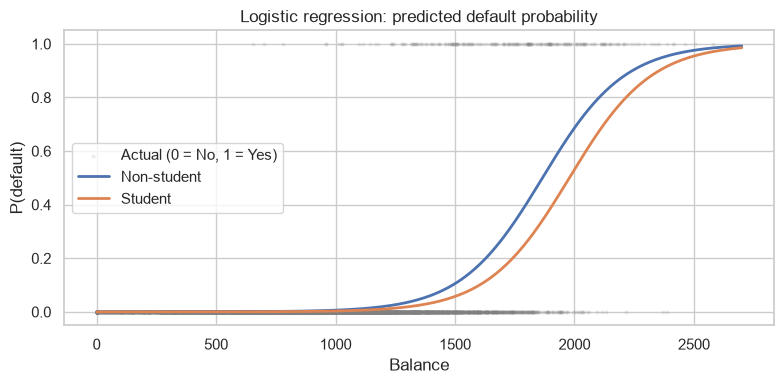

In [7]:
bal = np.linspace(0, 2700, 300)
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(train["balance"], train["default_flag"], s=4, alpha=0.1, color="grey", label="Actual (0 = No, 1 = Yes)")
for s, label in [(0, "Non-student"), (1, "Student")]:
    ax.plot(bal, final.predict(pd.DataFrame({"balance": bal, "is_student": s})), lw=2, label=label)
ax.set(title="Logistic regression: predicted default probability", xlabel="Balance", ylabel="P(default)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "08_logistic_curve.png", dpi=150)
plt.show()

**How to read:** grey dots at the bottom (0) and top (1) are real customers who did not / did default. The lines are the model's chance of default at each balance.
**Look for:** the S-shape – risk is near 0 until about 1,000, then climbs fast. The orange (student) line is always below the blue (non-student) line.

**วิธีอ่าน:** จุดสีเทาด้านล่าง (0) และด้านบน (1) คือลูกค้าจริงที่ไม่ผิดนัด / ผิดนัด เส้นคือโอกาสผิดนัดที่โมเดลทำนายในแต่ละยอดหนี้
**สังเกต:** เส้นรูปตัว S – ความเสี่ยงใกล้ 0 จนถึงประมาณ 1,000 แล้วพุ่งขึ้นเร็ว เส้นสีส้ม (นักศึกษา) อยู่ต่ำกว่าเส้นสีน้ำเงิน (ไม่ใช่นักศึกษา) เสมอ

**Insight:** risk is almost **0% below a balance of 1,000**, then explodes: a non-student goes from **10.6% at 1,500 to 68.7% at 2,000**. At every balance, the student curve sits **below** the non-student curve (e.g. 2,000: **53.2% vs 68.7%**).

**ข้อค้นพบ:** ยอดหนี้ต่ำกว่า 1,000 ความเสี่ยงเกือบ **0%** แล้วพุ่งขึ้นมาก: คนทั่วไปจาก **10.6% ที่ยอด 1,500 เป็น 68.7% ที่ยอด 2,000** และที่ทุกยอดหนี้ นักศึกษาเสี่ยงน้อยกว่า (เช่น ที่ 2,000: **53.2% เทียบกับ 68.7%**)

## 4. Compare models (10-fold cross-validation on the training set) / เปรียบเทียบโมเดล 8 แบบ
- **AUC**: how well the model ranks defaulters above non-defaulters (0.5 = random, 1 = perfect).
- **PR-AUC**: like AUC but focused on the rare "Yes" group – more honest for imbalanced data (random ≈ 0.033).

ทดสอบโมเดล 8 แบบด้วยวิธี cross-validation (แบ่งข้อมูลฝึกเป็น 10 ส่วน ฝึก 9 ส่วน ทดสอบ 1 ส่วน วนจนครบ) แล้วเทียบคะแนน **AUC** และ **PR-AUC** (ยิ่งสูงยิ่งดี)

In [8]:
ALL = ["balance", "is_student", "income"]
BS = ["balance", "is_student"]
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

candidates = {
    "Logistic (balance + student)": (BS, make_pipeline(StandardScaler(), LogisticRegression())),
    "Logistic (all 3)": (ALL, make_pipeline(StandardScaler(), LogisticRegression())),
    "LDA": (ALL, LinearDiscriminantAnalysis()),
    "QDA": (ALL, QuadraticDiscriminantAnalysis()),
    "Naive Bayes": (ALL, GaussianNB()),
    "KNN (k=25)": (ALL, make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=25))),
    "Random Forest": (ALL, RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=SEED)),
    "Gradient Boosting": (ALL, HistGradientBoostingClassifier(random_state=SEED)),
}

rows, cv_probs = [], {}
for name, (cols, model) in candidates.items():
    p = cross_val_predict(model, train[cols], y_train, cv=cv, method="predict_proba")[:, 1]
    cv_probs[name] = p
    rows.append({
        "model": name,
        "AUC": roc_auc_score(y_train, p),
        "PR_AUC": average_precision_score(y_train, p),
        "recall@0.5": recall_score(y_train, p >= 0.5),
        "precision@0.5": precision_score(y_train, p >= 0.5, zero_division=0),
    })

comparison = pd.DataFrame(rows).sort_values("AUC", ascending=False).reset_index(drop=True).round(3)
comparison

,model,AUC,PR_AUC,recall@0.5,precision@0.5
0,Logistic (balance + student),0.948,0.542,0.318,0.755
1,LDA,0.948,0.543,0.240,0.824
2,Logistic (all 3),0.948,0.541,0.318,0.755
3,QDA,0.947,0.536,0.270,0.768
4,Naive Bayes,0.944,0.482,0.270,0.663
5,Random Forest,0.926,0.498,0.365,0.702
6,Gradient Boosting,0.924,0.445,0.339,0.577
7,KNN (k=25),0.895,0.468,0.283,0.742


**Insight:**
- **Logistic regression, LDA and QDA tie** at the top (AUC **0.947–0.948**, PR-AUC about **0.54**).
- **Complex models do worse**: Random Forest **0.926**, Gradient Boosting **0.924**, KNN **0.895**. With only 3 simple predictors and a smooth S-shaped pattern, there is nothing hidden for them to find – they just fit noise.
- **Logistic (balance + student)** scores the same as the 3-variable version with one less variable, and it is the easiest to explain → **chosen model**.
- At the default 0.5 cutoff, every model catches only **24–37%** of defaulters → the cutoff must be tuned.

**ข้อค้นพบ:**
- **Logistic regression, LDA และ QDA ดีที่สุดพอๆ กัน** (AUC **0.947–0.948**)
- **โมเดลซับซ้อนกลับแย่กว่า** (Random Forest 0.926, Gradient Boosting 0.924, KNN 0.895) เพราะข้อมูลมีแค่ 3 ตัวแปรและรูปแบบเรียบง่าย ไม่มีอะไรซ่อนให้ค้นหา
- เลือก **Logistic (balance + student)** เพราะแม่นเท่ากัน ใช้ตัวแปรน้อยกว่า และอธิบายง่ายที่สุด
- ที่เกณฑ์ 0.5 ทุกโมเดลจับคนผิดนัดได้แค่ **24–37%** → ต้องปรับเกณฑ์ตัดสิน

## 5. Tune the cutoff (threshold) / ปรับเกณฑ์ตัดสิน
By default a model flags "Yes" when P(default) ≥ 0.5. With rare defaults, that misses most of them.
We test cutoffs on the **training cross-validation predictions** (not the test set, so the final check stays fair) and pick the one with the best **F1** (a balance of recall and precision).

ปกติโมเดลจะแจ้งเตือนเมื่อโอกาสผิดนัด ≥ 50% แต่คนผิดนัดมีน้อย จึงหลุดไปเกือบหมด เราลองเกณฑ์หลายค่ากับข้อมูลฝึก (ไม่ใช้ข้อมูลทดสอบ เพื่อให้การตรวจสุดท้ายยุติธรรม) แล้วเลือกค่าที่ได้ **F1** สูงสุด (ค่าสมดุลระหว่าง recall และ precision)

In [9]:
p_cv = cv_probs["Logistic (balance + student)"]
thresholds = np.round(np.arange(0.05, 0.55, 0.05), 2)

tradeoff = pd.DataFrame([{
    "threshold": t,
    "recall": recall_score(y_train, p_cv >= t),
    "precision": precision_score(y_train, p_cv >= t, zero_division=0),
    "F1": f1_score(y_train, p_cv >= t),
    "flagged_pct": 100 * (p_cv >= t).mean(),
} for t in thresholds]).round(3)

best_t = float(tradeoff.loc[tradeoff["F1"].idxmax(), "threshold"])
print(f"Best cutoff by F1: {best_t}")
tradeoff

Best cutoff by F1: 0.3


,threshold,recall,precision,F1,flagged_pct
0,0.05,0.841,0.221,0.350,12.657
1,0.10,0.721,0.303,0.426,7.929
2,0.15,0.661,0.364,0.470,6.043
3,0.20,0.614,0.428,0.504,4.771
4,0.25,0.558,0.498,0.526,3.729
5,0.30,0.502,0.565,0.532,2.957
6,0.35,0.464,0.617,0.529,2.500
7,0.40,0.412,0.662,0.508,2.071
8,0.45,0.356,0.735,0.480,1.614
9,0.50,0.318,0.755,0.447,1.400


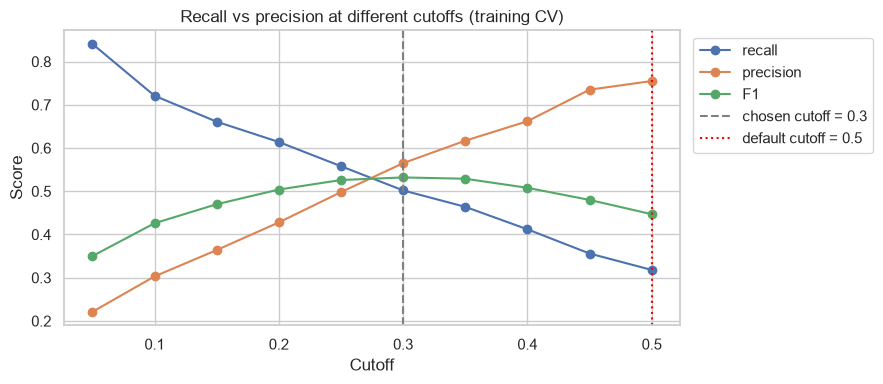

In [18]:
fig, ax = plt.subplots(figsize=(9, 4))
for col in ["recall", "precision", "F1"]:
    ax.plot(tradeoff["threshold"], tradeoff[col], marker="o", label=col)
ax.axvline(best_t, color="grey", ls="--", label=f"chosen cutoff = {best_t}")
ax.axvline(0.5, color="red", ls=":", label="default cutoff = 0.5")
ax.set(title="Recall vs precision at different cutoffs (training CV)", xlabel="Cutoff", ylabel="Score")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
fig.tight_layout()
fig.savefig(FIG_DIR / "09_threshold_tradeoff.png", dpi=150)
plt.show()

**How to read:** the bottom axis is the cutoff. Blue = recall (share of defaulters caught), orange = precision (share of flags that are right), green = F1 (a balance of both).
**Look for:** moving the cutoff left catches more defaulters but gives more false alarms. The grey dashed line (0.3) is where F1 is highest.

**วิธีอ่าน:** แกนนอนคือเกณฑ์ตัดสิน สีน้ำเงิน = recall (จับคนผิดนัดได้กี่ %) สีส้ม = precision (แจ้งเตือนถูกกี่ %) สีเขียว = F1 (ค่าสมดุลของทั้งสอง)
**สังเกต:** ยิ่งเลื่อนเกณฑ์ไปทางซ้าย ยิ่งจับคนผิดนัดได้มาก แต่แจ้งเตือนผิดมากขึ้น เส้นประสีเทา (0.3) คือจุดที่ F1 สูงสุด

**Insight:** the best F1 is at a cutoff of **0.3** (recall **50%**, precision **57%**). A lower cutoff catches more defaulters but raises more false alarms:

| Cutoff | Defaulters caught (recall) | Flags that are correct (precision) |
|---|---|---|
| 0.5 | 32% | 76% |
| **0.3** | **50%** | **57%** |
| 0.2 | 61% | 43% |
| 0.1 | 72% | 30% |

The "right" cutoff is a **business choice**: if missing a defaulter costs much more than checking a false alarm, use a lower cutoff (e.g. 0.2 or 0.1).

**ข้อค้นพบ:** เกณฑ์ที่ได้ F1 ดีที่สุดคือ **0.3** (จับคนผิดนัดได้ **50%** แจ้งเตือนถูก **57%**) ยิ่งลดเกณฑ์ ยิ่งจับคนผิดนัดได้มาก แต่แจ้งเตือนผิดมากขึ้น เกณฑ์ที่ "ถูกต้อง" จึงเป็น **การตัดสินใจทางธุรกิจ**: ถ้าการพลาดคนผิดนัดเสียหายมากกว่าการตรวจสอบแจ้งเตือนผิดมาก ให้ใช้เกณฑ์ต่ำลง (เช่น 0.2 หรือ 0.1)

## 6. Final check on the test set / ตรวจสอบครั้งสุดท้ายกับข้อมูลทดสอบ
The final model (logistic regression, `balance + is_student`, fitted on the training set) now sees the test set for the first time.

โมเดลสุดท้ายได้เห็นข้อมูลทดสอบ (ลูกค้า 3,000 คน) เป็นครั้งแรก ผลตรงนี้จึงบอกว่าโมเดลจะทำงานได้ดีแค่ไหนกับลูกค้าใหม่

In [11]:
test_pred = test[["customer_id", "default_flag", "balance", "is_student"]].assign(
    prob_default=final.predict(test).to_numpy()
)
con.register("test_predictions", test_pred)
p_test = test_pred["prob_default"]

pd.DataFrame([{
    "cutoff": t,
    "accuracy": ((p_test >= t) == y_test).mean(),
    "recall": recall_score(y_test, p_test >= t),
    "precision": precision_score(y_test, p_test >= t),
    "F1": f1_score(y_test, p_test >= t),
    "AUC": roc_auc_score(y_test, p_test),
    "PR_AUC": average_precision_score(y_test, p_test),
} for t in [0.5, best_t]]).round(3)

,cutoff,accuracy,recall,precision,F1,AUC,PR_AUC
0,0.5,0.972,0.33,0.660,0.44,0.951,0.503
1,0.3,0.966,0.53,0.491,0.51,0.951,0.503


In [12]:
run("confusion_matrix", threshold=0.5)

```sql
WITH c AS (
    SELECT
        COUNT(*) FILTER (WHERE default_flag = 1 AND prob_default >= $threshold) AS caught_defaulters,
        COUNT(*) FILTER (WHERE default_flag = 1 AND prob_default <  $threshold) AS missed_defaulters,
        COUNT(*) FILTER (WHERE default_flag = 0 AND prob_default >= $threshold) AS false_alarms,
        COUNT(*) FILTER (WHERE default_flag = 0 AND prob_default <  $threshold) AS correct_no
    FROM test_predictions
)
SELECT
    *,
    ROUND(100.0 * caught_defaulters / (caught_defaulters + missed_defaulters), 1)       AS recall_pct,
    ROUND(100.0 * caught_defaulters / NULLIF(caught_defaulters + false_alarms, 0), 1)   AS precision_pct
FROM c;
```

Parameters: `{'threshold': 0.5}`

,caught_defaulters,missed_defaulters,false_alarms,correct_no,recall_pct,precision_pct
0,33,67,17,2883,33.0,66.0


In [13]:
run("confusion_matrix", threshold=best_t)

```sql
WITH c AS (
    SELECT
        COUNT(*) FILTER (WHERE default_flag = 1 AND prob_default >= $threshold) AS caught_defaulters,
        COUNT(*) FILTER (WHERE default_flag = 1 AND prob_default <  $threshold) AS missed_defaulters,
        COUNT(*) FILTER (WHERE default_flag = 0 AND prob_default >= $threshold) AS false_alarms,
        COUNT(*) FILTER (WHERE default_flag = 0 AND prob_default <  $threshold) AS correct_no
    FROM test_predictions
)
SELECT
    *,
    ROUND(100.0 * caught_defaulters / (caught_defaulters + missed_defaulters), 1)       AS recall_pct,
    ROUND(100.0 * caught_defaulters / NULLIF(caught_defaulters + false_alarms, 0), 1)   AS precision_pct
FROM c;
```

Parameters: `{'threshold': 0.3}`

,caught_defaulters,missed_defaulters,false_alarms,correct_no,recall_pct,precision_pct
0,53,47,55,2845,53.0,49.1


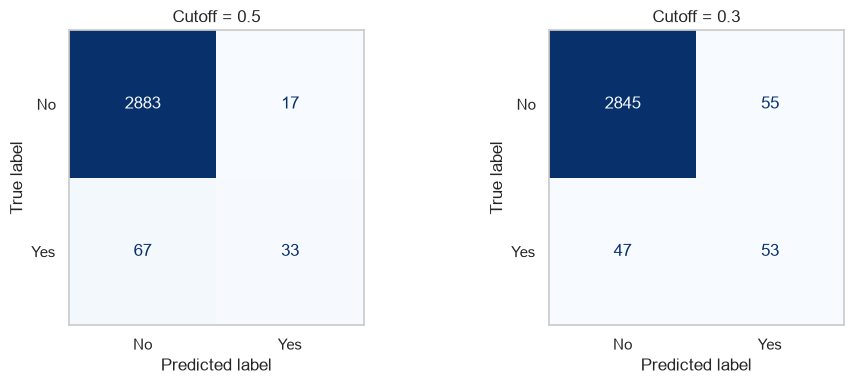

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, t in zip(axes, [0.5, best_t]):
    ConfusionMatrixDisplay.from_predictions(y_test, (p_test >= t).astype(int), display_labels=["No", "Yes"],
                                            cmap="Blues", colorbar=False, ax=ax)
    ax.grid(False)
    ax.set_title(f"Cutoff = {t}")
fig.tight_layout()
fig.savefig(FIG_DIR / "10_confusion_matrices.png", dpi=150)
plt.show()

**How to read:** rows = what really happened, columns = what the model said. Bottom-right = defaulters caught. Bottom-left = defaulters missed. Top-right = false alarms.
**Look for:** with cutoff 0.3 (right), caught defaulters rise from 33 to 53, while false alarms rise from 17 to 55.

**วิธีอ่าน:** แถว = สิ่งที่เกิดขึ้นจริง คอลัมน์ = สิ่งที่โมเดลทาย มุมขวาล่าง = จับคนผิดนัดได้ มุมซ้ายล่าง = คนผิดนัดที่หลุดไป มุมขวาบน = แจ้งเตือนผิด
**สังเกต:** เมื่อใช้เกณฑ์ 0.3 (รูปขวา) จับคนผิดนัดได้เพิ่มจาก 33 เป็น 53 คน แต่แจ้งเตือนผิดเพิ่มจาก 17 เป็น 55 คน

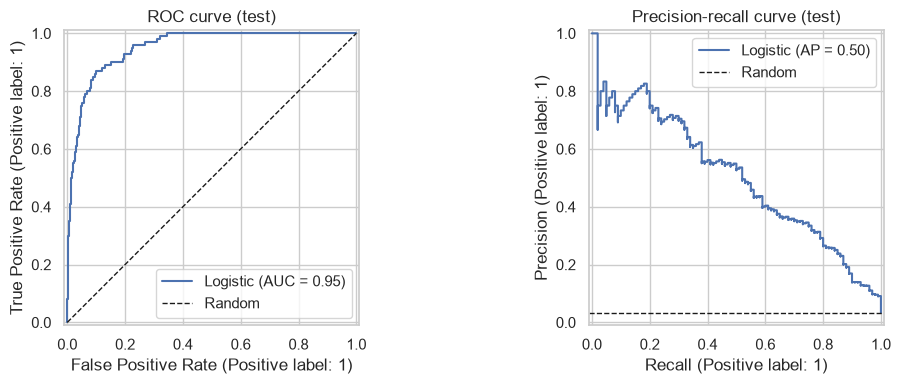

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_test, p_test, name="Logistic", ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
axes[0].set_title("ROC curve (test)")
axes[0].legend()
PrecisionRecallDisplay.from_predictions(y_test, p_test, name="Logistic", ax=axes[1])
axes[1].axhline(y_test.mean(), color="k", ls="--", lw=1, label="Random")
axes[1].set_title("Precision-recall curve (test)")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "11_roc_pr_curves.png", dpi=150)
plt.show()

**How to read:** left (ROC) – the more the curve bends toward the top-left corner, the better; the dashed line is random guessing. Right (precision–recall) – the higher the curve, the better; the dashed line is guessing (3.3%).
**Look for:** AUC = 0.95, far above guessing (0.5). The model ranks risky customers very well.

**วิธีอ่าน:** รูปซ้าย (ROC) – เส้นยิ่งโค้งเข้ามุมซ้ายบนยิ่งดี เส้นประคือการเดาสุ่ม รูปขวา (precision–recall) – เส้นยิ่งสูงยิ่งดี เส้นประคือการเดา (3.3%)
**สังเกต:** AUC = 0.95 สูงกว่าการเดาสุ่ม (0.5) มาก โมเดลจัดอันดับลูกค้าเสี่ยงได้ดีมาก

**Insight (test set, 3,000 customers, 100 defaulters):**
- **Test AUC = 0.951**, very close to the training CV AUC (0.948) → the model **does not overfit** and works on new data.
- **Cutoff 0.5:** catches **33 of 100** defaulters, with 17 false alarms.
- **Cutoff 0.3:** catches **53 of 100** defaulters (+20), with 55 false alarms (+38).
- Accuracy drops from 97.2% to 96.6% – even slightly **below** the "always No" baseline (96.7%). But the baseline catches **0** defaulters, while this model catches **53**. This shows again why accuracy is the wrong score here.

**ข้อค้นพบ (ข้อมูลทดสอบ 3,000 คน ผิดนัด 100 คน):**
- **AUC = 0.951** ใกล้เคียงตอนฝึก (0.948) → โมเดล **ไม่ได้จำข้อมูลฝึกมากเกินไป (ไม่ overfit)** ใช้กับลูกค้าใหม่ได้
- **เกณฑ์ 0.5:** จับได้ **33 จาก 100** คน แจ้งเตือนผิด 17 คน
- **เกณฑ์ 0.3:** จับได้ **53 จาก 100** คน (+20) แจ้งเตือนผิด 55 คน (+38)
- ความแม่นยำ (accuracy) ลดลงเล็กน้อยจนต่ำกว่าการตอบ "ไม่ผิดนัด" ทุกครั้ง (96.7%) แต่แบบนั้นจับคนผิดนัดได้ **0** คน ส่วนโมเดลนี้จับได้ **53** คน → accuracy ไม่ใช่ตัววัดที่ถูกต้องในงานนี้

## 7. Business view (SQL) / มุมมองทางธุรกิจ
How well does the model **rank** customers? If the bank reviews only the riskiest customers first, how many defaulters does it find?

โมเดล **จัดอันดับ** ลูกค้าได้ดีแค่ไหน? ถ้าธนาคารตรวจเฉพาะลูกค้าที่เสี่ยงที่สุดก่อน จะเจอคนผิดนัดกี่คน?

In [16]:
run("risk_deciles")

```sql
-- Decile 1 = the 10% of customers the model thinks are most risky.
WITH ranked AS (
    SELECT *, NTILE(10) OVER (ORDER BY prob_default DESC) AS decile
    FROM test_predictions
)
SELECT
    decile,
    COUNT(*)                                AS n,
    CAST(SUM(default_flag) AS INTEGER)      AS n_default,
    ROUND(100 * AVG(default_flag), 2)       AS actual_default_rate_pct,
    ROUND(100 * MIN(prob_default), 2)       AS min_predicted_pct,
    ROUND(100 * MAX(prob_default), 2)       AS max_predicted_pct,
    ROUND(100.0 * SUM(SUM(default_flag)) OVER (ORDER BY decile)
                / SUM(SUM(default_flag)) OVER (), 1) AS cum_pct_of_defaulters
FROM ranked
GROUP BY decile
ORDER BY decile;
```

,decile,n,n_default,actual_default_rate_pct,min_predicted_pct,max_predicted_pct,cum_pct_of_defaulters
0,1,300,80,26.67,7.88,98.11,80.0
1,2,300,10,3.33,2.08,7.87,90.0
2,3,300,7,2.33,0.89,2.07,97.0
3,4,300,3,1.00,0.39,0.89,100.0
4,5,300,0,0.00,0.18,0.39,100.0
5,6,300,0,0.00,0.08,0.18,100.0
6,7,300,0,0.00,0.04,0.08,100.0
7,8,300,0,0.00,0.01,0.04,100.0
8,9,300,0,0.00,0.00,0.01,100.0
9,10,300,0,0.00,0.00,0.00,100.0


In [17]:
run("risk_bands")

```sql
SELECT
    CASE
        WHEN prob_default < 0.05 THEN '1. Low (<5%)'
        WHEN prob_default < 0.20 THEN '2. Medium (5-20%)'
        WHEN prob_default < 0.50 THEN '3. High (20-50%)'
        ELSE '4. Very high (50%+)'
    END                                                            AS risk_band,
    COUNT(*)                                                       AS n_customers,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)             AS pct_of_customers,
    CAST(SUM(default_flag) AS INTEGER)                             AS n_default,
    ROUND(100 * AVG(prob_default), 1)                              AS avg_predicted_pct,
    ROUND(100 * AVG(default_flag), 1)                              AS actual_default_rate_pct,
    ROUND(100.0 * SUM(default_flag) / SUM(SUM(default_flag)) OVER (), 1) AS pct_of_all_defaulters
FROM test_predictions
GROUP BY risk_band
ORDER BY risk_band;
```

,risk_band,n_customers,pct_of_customers,n_default,avg_predicted_pct,actual_default_rate_pct,pct_of_all_defaulters
0,1. Low (<5%),2623,87.4,14,0.6,0.5,14.0
1,2. Medium (5-20%),219,7.3,24,10.5,11.0,24.0
2,3. High (20-50%),108,3.6,29,31.9,26.9,29.0
3,4. Very high (50%+),50,1.7,33,71.4,66.0,33.0


**Insight:**
- **The model ranks customers very well.** The riskiest **10%** of customers contain **80%** of all defaulters. The top **30%** contain **97%**. The bottom 60% contain **zero**.
- **The probabilities can be trusted as real percentages.** In each band, predicted and actual default rates are close (0.6% vs 0.5%, 10.5% vs 11.0%, 31.9% vs 26.9%, 71.4% vs 66.0%). The model slightly over-predicts in the top bands.
- **Suggested use by the bank:**

| Risk band | Customers | Share of all defaulters | Action |
|---|---|---|---|
| Low (<5%) | 87.4% | 14% | Normal |
| Medium (5–20%) | 7.3% | 24% | Monitor |
| High + Very high (20%+) | **5.3%** | **62%** | Act: contact, lower limit, payment plan |

**ข้อค้นพบ:**
- **โมเดลจัดอันดับลูกค้าได้ดีมาก:** ลูกค้าที่เสี่ยงที่สุด **10%** รวมคนผิดนัดไว้ถึง **80%** กลุ่มเสี่ยงสุด 30% รวมไว้ **97%** ส่วนลูกค้า 60% ล่างสุด **ไม่มีคนผิดนัดเลย**
- **เชื่อตัวเลขโอกาสผิดนัดได้:** ในแต่ละกลุ่ม ค่าที่ทำนายใกล้กับค่าจริง (เช่น 10.5% เทียบกับ 11.0%) กลุ่มบนสุดโมเดลประเมินสูงกว่าจริงเล็กน้อย
- **แนะนำ:** กลุ่ม High + Very high มีลูกค้าแค่ **5.3%** แต่มีคนผิดนัด **62%** → ควรติดต่อ ลดวงเงิน หรือเสนอแผนผ่อนชำระกับกลุ่มนี้ก่อน (ดูรายละเอียดใน `04_tariff_recommendation.ipynb`)

## 8. Summary / สรุป

**Final model:** logistic regression with `balance` + `is_student`, cutoff **0.3**.

| Question | Answer |
|---|---|
| What drives default? | **Balance.** Every +100 multiplies the odds by **1.79** |
| Are students riskier? | **No.** At the same balance, students have **48% lower** odds. They only look riskier because they carry higher balances (Simpson's paradox) |
| Does income matter? | **No** (p = 0.86). Dropped from the model |
| Best model? | Logistic regression. It ties LDA/QDA and beats Random Forest, Gradient Boosting and KNN, and it is the easiest to explain |
| How good on new data? | Test AUC **0.951**. Catches **53 of 100** defaulters at cutoff 0.3 (vs 33 at 0.5, and 0 for the baseline) |
| Business value | The riskiest **10%** of customers hold **80%** of defaulters. The **5.3%** of customers flagged High/Very high hold **62%** |

**Limitations:**
- The data is **simulated**, so real bank data may behave differently.
- Only 3 predictors. Real credit models also use payment history, credit limit, age, etc.
- There is no time information, so we can say balance is **linked** to default, not that it **causes** it.
- The best cutoff depends on the real cost of a missed defaulter vs a false alarm, which this data does not include.

**สรุปภาษาไทย**

**โมเดลสุดท้าย:** logistic regression ใช้ `balance` + `is_student` เกณฑ์ตัดสิน **0.3**

| คำถาม | คำตอบ |
|---|---|
| อะไรทำให้ผิดนัด? | **ยอดหนี้** – เพิ่มทุก 100 โอกาส (odds) ผิดนัดเพิ่ม **1.79 เท่า** |
| นักศึกษาเสี่ยงกว่าไหม? | **ไม่** – ที่ยอดหนี้เท่ากัน odds ต่ำกว่า **48%** ที่ดูเสี่ยงกว่าเพราะมียอดหนี้สูงกว่า (Simpson's paradox) |
| รายได้มีผลไหม? | **ไม่** (p = 0.86) จึงตัดออกจากโมเดล |
| โมเดลไหนดีที่สุด? | Logistic regression – แม่นเท่า LDA/QDA ดีกว่าโมเดลซับซ้อน และอธิบายง่ายที่สุด |
| แม่นแค่ไหนกับลูกค้าใหม่? | AUC **0.951** จับคนผิดนัดได้ **53 จาก 100** คนที่เกณฑ์ 0.3 (เกณฑ์ 0.5 ได้ 33 คน ค่าพื้นฐานได้ 0 คน) |
| คุณค่าทางธุรกิจ | ลูกค้าเสี่ยงสุด **10%** รวมคนผิดนัดไว้ **80%** |

**ข้อจำกัด:** ข้อมูลเป็นข้อมูลจำลอง มีแค่ 3 ตัวแปร ไม่มีข้อมูลเวลา (บอกได้แค่ว่ายอดหนี้ "สัมพันธ์" กับการผิดนัด ไม่ใช่ "เป็นสาเหตุ") และเกณฑ์ที่ดีที่สุดขึ้นกับต้นทุนจริงของธนาคาร